Life Expectancy Analysis — Project 2 (Python)
Replication and extension of Project 1 (Power BI) using Python, pandas, and statistical modelling. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load datasets
who = pd.read_excel('Data/Life Expectancy Data.xlsx')
gdp = pd.read_csv('Data/WB_GDP_per_capita_clean.csv')
pop = pd.read_csv('Data/WB_Population_clean.csv')

print(f"WHO dataset: {who.shape[0]} rows, {who.shape[1]} columns, {who['Country'].nunique()} countries")
print(f"GDP dataset: {gdp.shape[0]} rows, {gdp['Country'].nunique()} countries")
print(f"Population dataset: {pop.shape[0]} rows, {pop['Country'].nunique()} countries")

WHO dataset: 2938 rows, 22 columns, 193 countries
GDP dataset: 2865 rows, 191 countries
Population dataset: 3056 rows, 191 countries


In [3]:
#shows titles of data list
import os
os.listdir('Data')

['Life Expectancy Data.xlsx',
 'WB_GDP_per_capita_clean.csv',
 'WB_Population_clean.csv']

In [4]:
# shows preview of first 10 rows
who.head(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


In [5]:
# Interactive table — sort, filter, search
# pip install itables (run once in terminal if not installed)
from itables import show
show(who, scrollY="500px", scrollCollapse=True, paging=False)

Loading ITables v2.7.3 from the internet... (need help?)


In [6]:
# Check if any Country appears more than 16 times (2000-2015 = 16 years max)
country_counts = who.groupby('Country')['Year'].count()
over = country_counts[country_counts > 16]
print(f"Countries with more than 16 rows: {len(over)}")
if len(over) > 0:
    print(over)

# Also check if any Country-Year pair has different values
dupes_full = who[who.duplicated(subset=['Country', 'Year'], keep=False)]
print(f"\nExact Country-Year duplicates (checking all columns): {len(dupes_full)}")


Countries with more than 16 rows: 0

Exact Country-Year duplicates (checking all columns): 0


In [7]:
# Check unique values in categorical columns
print(f"Countries: {who['Country'].nunique()}")
print(f"Years: {sorted(who['Year'].unique())}")
print(f"Status values: {who['Status'].unique()}")
print(f"Status distribution:\n{who['Status'].value_counts()}")

Countries: 193
Years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]
Status values: ['Developing' 'Developed']
Status distribution:
Status
Developing    2426
Developed      512
Name: count, dtype: int64


In [8]:
#shows non-nulls count
who.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [9]:
# Show breakdown of nulls and non-nulls
pd.DataFrame({
    'dtype': who.dtypes,
    'non_null': who.notnull().sum(),
    'nulls': who.isnull().sum(),
    'null_pct': (who.isnull().sum() / len(who) * 100).round(1)
}).sort_values('nulls', ascending=False)

,dtype,non_null,nulls,null_pct
Population,float64,2286,652,22.2
Hepatitis B,float64,2385,553,18.8
GDP,float64,2490,448,15.2
Total expenditure,float64,2712,226,7.7
Alcohol,float64,2744,194,6.6
Income composition of resources,float64,2771,167,5.7
Schooling,float64,2775,163,5.5
thinness 1-19 years,float64,2904,34,1.2
thinness 5-9 years,float64,2904,34,1.2
BMI,float64,2904,34,1.2


In [10]:
#shows column information
pd.set_option('display.float_format', '{:.2f}'.format)
who.describe()


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.00,2928.00,2928.00,2938.00,2744.00,2938.00,2385.00,2938.00,2904.00,2938.00,2919.00,2712.00,2919.00,2938.00,2490.00,2286.00,2904.00,2904.00,2771.00,2775.00
mean,2007.52,69.22,164.80,30.30,4.60,738.25,80.94,2419.59,38.32,42.04,82.55,5.94,82.32,1.74,7483.16,12753375.12,4.84,4.87,0.63,11.99
std,4.61,9.52,124.29,117.93,4.05,1987.91,25.07,11467.27,20.04,160.45,23.43,2.50,23.72,5.08,14270.17,61012096.51,4.42,4.51,0.21,3.36
min,2000.00,36.30,1.00,0.00,0.01,0.00,1.00,0.00,1.00,0.00,3.00,0.37,2.00,0.10,1.68,34.00,0.10,0.10,0.00,0.00
25%,2004.00,63.10,74.00,0.00,0.88,4.69,77.00,0.00,19.30,0.00,78.00,4.26,78.00,0.10,463.94,195793.25,1.60,1.50,0.49,10.10
50%,2008.00,72.10,144.00,3.00,3.75,64.91,92.00,17.00,43.50,4.00,93.00,5.75,93.00,0.10,1766.95,1386542.00,3.30,3.30,0.68,12.30
75%,2012.00,75.70,228.00,22.00,7.70,441.53,97.00,360.25,56.20,28.00,97.00,7.49,97.00,0.80,5910.81,7420359.00,7.20,7.20,0.78,14.30
max,2015.00,89.00,723.00,1800.00,17.87,19479.91,99.00,212183.00,87.30,2500.00,99.00,17.60,99.00,50.60,119172.74,1293859294.00,27.70,28.60,0.95,20.70


In [11]:
# Check for suspiciously low values in percentage-based columns (should be 0-100)
pct_cols = ['Hepatitis B', 'Polio', 'Diphtheria ', ' BMI ']
for col in pct_cols:
    low_vals = who[who[col] < 10][col]
    if len(low_vals) > 0:
        print(f"{col.strip()}: {len(low_vals)} values below 10 — min is {low_vals.min()}")
        

Hepatitis B: 159 values below 10 — min is 1.0
Polio: 172 values below 10 — min is 3.0
Diphtheria: 170 values below 10 — min is 2.0
BMI: 283 values below 10 — min is 1.0


In [12]:
# Anomaly scan — flags anything suspicious across all numeric columns
for col in who.select_dtypes(include='number').columns:
    if col == 'Year':
        continue
    series = who[col].dropna()
    print(f"\n--- {col.strip()} ---")
    print(f"  Range: {series.min()} to {series.max()}")
    
    # Flag zeros in columns where zero is suspicious
    zeros = (series == 0).sum()
    if zeros > 0:
        print(f"  ⚠ {zeros} zero values")
    
    # Flag values below 10 in percentage columns (should be 0-100)
    if series.max() <= 100 and series.min() >= 0:
        low = (series < 10).sum()
        if low > 0:
            print(f"  ⚠ {low} values below 10")


--- Life expectancy ---
  Range: 36.3 to 89.0

--- Adult Mortality ---
  Range: 1.0 to 723.0

--- infant deaths ---
  Range: 0 to 1800
  ⚠ 848 zero values

--- Alcohol ---
  Range: 0.01 to 17.87
  ⚠ 2371 values below 10

--- percentage expenditure ---
  Range: 0.0 to 19479.91161
  ⚠ 611 zero values

--- Hepatitis B ---
  Range: 1.0 to 99.0
  ⚠ 159 values below 10

--- Measles ---
  Range: 0 to 212183
  ⚠ 983 zero values

--- BMI ---
  Range: 1.0 to 87.3
  ⚠ 283 values below 10

--- under-five deaths ---
  Range: 0 to 2500
  ⚠ 785 zero values

--- Polio ---
  Range: 3.0 to 99.0
  ⚠ 172 values below 10

--- Total expenditure ---
  Range: 0.37 to 17.6
  ⚠ 2609 values below 10

--- Diphtheria ---
  Range: 2.0 to 99.0
  ⚠ 170 values below 10

--- HIV/AIDS ---
  Range: 0.1 to 50.6
  ⚠ 2810 values below 10

--- GDP ---
  Range: 1.68135 to 119172.7418

--- Population ---
  Range: 34.0 to 1293859294.0

--- thinness  1-19 years ---
  Range: 0.1 to 27.7
  ⚠ 2632 values below 10

--- thinness 5-9

In [13]:
# Change to True to run full anomaly scan
RUN_ANOMALY_SCAN = True

if RUN_ANOMALY_SCAN:
    from IPython.display import display, HTML
    all_anomalies = []
    
    cols_to_check = ['Hepatitis B', 'Polio', 'Diphtheria ', ' BMI ', 
                     'Schooling', 'Income composition of resources', 'Population', 'GDP']
    for col in cols_to_check:
        if col not in who.columns:
            continue
        
        for country, group in who.groupby('Country'):
            g = group.sort_values('Year')
            vals = g[col].values
            years = g['Year'].values
            
            for i in range(len(vals)):
                if pd.isna(vals[i]):
                    continue
                prev_val = next((vals[j] for j in range(i-1, -1, -1) if not pd.isna(vals[j])), None)
                next_val = next((vals[j] for j in range(i+1, len(vals)) if not pd.isna(vals[j])), None)
                
                if prev_val is not None and next_val is not None and prev_val != 0:
                    drop_from_prev = abs(vals[i] - prev_val) / max(abs(prev_val), 1)
                    drop_from_next = abs(vals[i] - next_val) / max(abs(next_val), 1)
                    
                    if drop_from_prev > 0.5 and drop_from_next > 0.5:
                        all_anomalies.append({
                            'Column': col.strip(), 'Country': country, 'Year': years[i],
                            'prev': prev_val, 'value': vals[i], 'next': next_val
                        })
    
    if all_anomalies:
        df_anom = pd.DataFrame(all_anomalies)
        display(HTML(
            f'<h4>{len(df_anom)} suspicious values found</h4>'
            '<div style="height:400px; overflow-y:scroll; border:1px solid #ccc;">'
            + df_anom.to_html(index=False)
            + '</div>'
        ))
    else:
        print("No anomalies detected")
else:
    print("Anomaly scan skipped — set RUN_ANOMALY_SCAN = True to run")

Column,Country,Year,prev,value,next
Hepatitis B,Argentina,2008,85.00,9.00,94.00
Hepatitis B,Azerbaijan,2003,5.00,51.00,5.00
Hepatitis B,Azerbaijan,2004,51.00,5.00,49.00
Hepatitis B,Azerbaijan,2010,74.00,8.00,84.00
Hepatitis B,Bahamas,2008,93.00,9.00,95.00
Hepatitis B,Bangladesh,2004,5.00,11.00,45.00
Hepatitis B,Benin,2005,75.00,7.00,74.00
Hepatitis B,Benin,2012,75.00,8.00,77.00
Hepatitis B,Bolivia (Plurinational State of),2003,77.00,8.00,84.00
Hepatitis B,Bosnia and Herzegovina,2005,36.00,93.00,9.00


## Phase 1 — Data Cleaning
Replicating all Project 1 cleaning decisions, plus fixes that weren't possible in Power BI.

In [14]:
# Remove South Sudan — founded 2011, pre-2011 data invalid, post-2011 mostly missing
who = who[who['Country'] != 'South Sudan']

# Remove 10 countries that only have 1 row (2013) with null Life expectancy — no usable data
no_le_countries = who.groupby('Country')['Life expectancy '].apply(lambda x: x.notna().sum())
remove_countries = no_le_countries[no_le_countries == 0].index.tolist()
print(f"Removing {len(remove_countries)} countries with no LE data: {remove_countries}")
who = who[~who['Country'].isin(remove_countries)]

print(f"Rows: {len(who)}, Countries: {who['Country'].nunique()}")

Removing 10 countries with no LE data: ['Cook Islands', 'Dominica', 'Marshall Islands', 'Monaco', 'Nauru', 'Niue', 'Palau', 'Saint Kitts and Nevis', 'San Marino', 'Tuvalu']
Rows: 2912, Countries: 182


In [15]:
# Clean column names — remove all leading/trailing whitespace
who.columns = [c.strip() for c in who.columns]
print(who.columns.tolist())

['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [16]:
# Fix encoding issue
cote_variants = who[who['Country'].str.contains('te d', na=False)]['Country'].unique()
print(f"Found: {cote_variants}")
who['Country'] = who['Country'].replace(cote_variants[0], "Côte d'Ivoire")
print(f"After fix: {who[who['Country'].str.contains('te d', na=False)]['Country'].unique()}")

Found: ["CÃ´te d'Ivoire"]
After fix: ["Côte d'Ivoire"]


In [17]:
# ICOR zeros = non-recording, not genuine zero human development
# Schooling zeros = no country has 0 schooling, data is missing
who['Income composition of resources'] = who['Income composition of resources'].replace(0, np.nan)
who['Schooling'] = who['Schooling'].replace(0, np.nan)
print(f"ICOR nulls: {who['Income composition of resources'].isnull().sum()}")
print(f"Schooling nulls: {who['Schooling'].isnull().sum()}")

ICOR nulls: 279
Schooling nulls: 175


In [18]:
# Hep B, Polio, Diphtheria all have same systematic single-digit errors (7,8,9 etc.)
# Values below 10 mid-series surrounded by 70s-90s = data entry errors, not real coverage
# Replace values below 10 with NaN, then forward-fill within each country
for col in ['Hepatitis B', 'Polio', 'Diphtheria']:
    before = (who[col] < 10).sum()
    who[col] = who.groupby('Country')[col].transform(
        lambda x: x.where(x >= 10).ffill()
    )
    after = (who[col] < 10).sum()
    print(f"{col}: {before} values below 10 → {after} remaining")

Hepatitis B: 157 values below 10 → 0 remaining
Polio: 170 values below 10 → 0 remaining
Diphtheria: 169 values below 10 → 0 remaining


In [19]:
# Check and remove duplicate Country-Year pairs
dupes = who.duplicated(subset=['Country', 'Year'], keep='first')
print(f"Duplicate rows found: {dupes.sum()}")
if dupes.sum() > 0:
    who = who[~dupes]
    print(f"Rows after removing: {len(who)}")
else:
    print("No duplicates — verified clean")
    

Duplicate rows found: 0
No duplicates — verified clean


In [20]:
# Sort by Country and Year first — ffill/bfill depend on row order
who = who.sort_values(['Country', 'Year']).reset_index(drop=True)

# Alcohol — fill down (2015 missing values filled from 2014)
who['Alcohol'] = who.groupby('Country')['Alcohol'].transform(lambda x: x.ffill())

# BMI — fill up (sparse early-year gaps)
who['BMI'] = who.groupby('Country')['BMI'].transform(lambda x: x.bfill())

# Thinness columns — fill up
who['thinness  1-19 years'] = who.groupby('Country')['thinness  1-19 years'].transform(lambda x: x.bfill())
who['thinness 5-9 years'] = who.groupby('Country')['thinness 5-9 years'].transform(lambda x: x.bfill())

print("Nulls after filling:")
print(who[['Alcohol', 'BMI', 'thinness  1-19 years', 'thinness 5-9 years']].isnull().sum())

Nulls after filling:
Alcohol                  0
BMI                     16
thinness  1-19 years    16
thinness 5-9 years      16
dtype: int64


In [21]:
# Fix Côte d'Ivoire encoding in World Bank data to match WHO
gdp['Country'] = gdp['Country'].replace("CÃ\x83Â´te d'Ivoire", "Côte d'Ivoire")
pop['Country'] = pop['Country'].replace("CÃ\x83Â´te d'Ivoire", "Côte d'Ivoire")

# Check it matched
print(f"Côte d'Ivoire in GDP: {gdp[gdp['Country'].str.contains('ivoire', case=False, na=False)]['Country'].unique()}")
print(f"Côte d'Ivoire in Pop: {pop[pop['Country'].str.contains('ivoire', case=False, na=False)]['Country'].unique()}")

Côte d'Ivoire in GDP: ["CÃ´te d'Ivoire"]
Côte d'Ivoire in Pop: ["CÃ´te d'Ivoire"]


In [22]:
# Fix Côte d'Ivoire encoding in World Bank data to match WHO
gdp['Country'] = gdp['Country'].str.replace("CÃ´te d'Ivoire", "Côte d'Ivoire", regex=False)
pop['Country'] = pop['Country'].str.replace("CÃ´te d'Ivoire", "Côte d'Ivoire", regex=False)

# Replace unreliable WHO GDP and Population with World Bank data
who = who.drop(columns=['GDP', 'Population'])
who = who.merge(gdp[['Country', 'Year', 'GDP_per_capita']], on=['Country', 'Year'], how='left')
who = who.merge(pop[['Country', 'Year', 'Population']], on=['Country', 'Year'], how='left')

# Backfill GDP year 2000 from 2001 (WB extract started at 2001)
who['GDP_per_capita'] = who.groupby('Country')['GDP_per_capita'].transform(lambda x: x.bfill())

print(f"Shape: {who.shape}")
print(f"GDP nulls: {who['GDP_per_capita'].isnull().sum()}")
print(f"Population nulls: {who['Population'].isnull().sum()}")

Shape: (2912, 22)
GDP nulls: 20
Population nulls: 0


In [23]:
# 14 countries misclassified as Developing — corrected using World Bank classifications
developed_corrections = [
    'Canada', 'Finland', 'France', 'Greece', 'Estonia', 'Israel',
    'Republic of Korea', 'Qatar', 'United Arab Emirates', 'Kuwait',
    'Bahrain', 'Saudi Arabia', 'Russian Federation', 'Oman'
]
who.loc[who['Country'].isin(developed_corrections), 'Status'] = 'Developed'
print(f"Status distribution:\n{who['Status'].value_counts()}")

Status distribution:
Status
Developing    2176
Developed      736
Name: count, dtype: int64


In [24]:
# Verify cleaning results
pd.DataFrame({
    'nulls': who.isnull().sum(),
    'null_pct': (who.isnull().sum() / len(who) * 100).round(1)
}).sort_values('nulls', ascending=False)

,nulls,null_pct
Income composition of resources,279,9.60
Total expenditure,213,7.30
Schooling,175,6.00
Hepatitis B,156,5.40
GDP_per_capita,20,0.70
thinness 5-9 years,16,0.50
thinness 1-19 years,16,0.50
Polio,16,0.50
BMI,16,0.50
Diphtheria,10,0.30


In [25]:
# Investigate remaining nulls

# 1. Alcohol — which countries still have nulls after ffill?
alc_nulls = who[who['Alcohol'].isnull()].groupby('Country')['Year'].apply(list)
print(f"=== Alcohol nulls ({who['Alcohol'].isnull().sum()}) ===")
print(f"Countries affected: {len(alc_nulls)}")
print(alc_nulls.head(10))

# 2. GDP — which countries have no World Bank match?
gdp_nulls = who[who['GDP_per_capita'].isnull()].groupby('Country')['Year'].apply(list)
print(f"\n=== GDP nulls ({who['GDP_per_capita'].isnull().sum()}) ===")
print(f"Countries affected: {len(gdp_nulls)}")
print(gdp_nulls)

# 3. Hep B — are these countries with no Hep B data at all?
hepb_nulls = who[who['Hepatitis B'].isnull()].groupby('Country')['Year'].count()
print(f"\n=== Hep B nulls ({who['Hepatitis B'].isnull().sum()}) ===")
print(hepb_nulls.sort_values(ascending=False).head(20))

# 4. The 16-null columns — same countries?
bmi_null_countries = who[who['BMI'].isnull()]['Country'].unique()
pop_null_countries = who[who['Population'].isnull()]['Country'].unique()
print(f"\n=== 16-null columns ===")
print(f"BMI null countries: {bmi_null_countries}")
print(f"Population null countries: {pop_null_countries}")

# 5. Total expenditure
exp_nulls = who[who['Total expenditure'].isnull()].groupby('Country')['Year'].count()
print(f"\n=== Total expenditure nulls ({who['Total expenditure'].isnull().sum()}) ===")
print(f"Countries affected: {len(exp_nulls)}")
print(exp_nulls.sort_values(ascending=False).head(10))

=== Alcohol nulls (0) ===
Countries affected: 0
Series([], Name: Year, dtype: int64)

=== GDP nulls (20) ===
Countries affected: 2
Country
Democratic People's Republic of Korea    [2000, 2001, 2002, 2003, 2004, 2005, 2006, 200...
Eritrea                                                           [2012, 2013, 2014, 2015]
Name: Year, dtype: object

=== Hep B nulls (156) ===
Country
Denmark                                                 16
Finland                                                 16
Iceland                                                 16
Switzerland                                             16
Hungary                                                 16
Norway                                                  16
Japan                                                   16
Slovenia                                                16
United Kingdom of Great Britain and Northern Ireland    16
Congo                                                    2
Gabon                       

In [26]:
# Debug Alcohol ffill — check a specific country
print(who[who['Country'] == 'Algeria'][['Year', 'Alcohol']].sort_values('Year'))

    Year  Alcohol
32  2000     0.25
33  2001     0.23
34  2002     0.36
35  2003     0.34
36  2004     0.45
37  2005     0.50
38  2006     0.36
39  2007     0.44
40  2008     0.46
41  2009     0.50
42  2010     0.45
43  2011     0.56
44  2012     0.66
45  2013     0.53
46  2014     0.01
47  2015     0.01


In [27]:
[c for c in who.columns if 'bmi' in c.lower() or 'thin' in c.lower()]

['BMI', 'thinness  1-19 years', 'thinness 5-9 years']

## Phase 2 — Feature Engineering
WHO Region merge, calculated columns, and composite scores — replicating Project 1 features with Project 2 improvements.

In [28]:
# WHO Region mapping — grouped by region for readability
region_groups = {
    'African': [
        'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi',
        'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros',
        'Congo', "Côte d'Ivoire", 'Democratic Republic of the Congo', 'Equatorial Guinea',
        'Eritrea', 'Ethiopia', 'Gabon', 'Gambia', 'Ghana', 'Guinea', 'Guinea-Bissau',
        'Kenya', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania',
        'Mauritius', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda',
        'Sao Tome and Principe', 'Senegal', 'Seychelles', 'Sierra Leone', 'South Africa',
        'Swaziland', 'Togo', 'Uganda', 'United Republic of Tanzania', 'Zambia', 'Zimbabwe'
    ],
    'Americas': [
        'Antigua and Barbuda', 'Argentina', 'Bahamas', 'Barbados', 'Belize',
        'Bolivia (Plurinational State of)', 'Brazil', 'Canada', 'Chile', 'Colombia',
        'Costa Rica', 'Cuba', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Grenada',
        'Guatemala', 'Guyana', 'Haiti', 'Honduras', 'Jamaica', 'Mexico', 'Nicaragua',
        'Panama', 'Paraguay', 'Peru', 'Saint Lucia', 'Saint Vincent and the Grenadines',
        'Suriname', 'Trinidad and Tobago', 'United States of America', 'Uruguay',
        'Venezuela (Bolivarian Republic of)'
    ],
    'South-East Asia': [
        'Bangladesh', 'Bhutan', 'India', 'Indonesia', 'Maldives', 'Myanmar',
        'Nepal', 'Sri Lanka', 'Thailand', 'Timor-Leste',
        "Democratic People's Republic of Korea"
    ],
    'European': [
        'Armenia', 'Austria', 'Azerbaijan', 'Belarus', 'Belgium',
        'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia',
        'Denmark', 'Estonia', 'Finland', 'France', 'Georgia', 'Germany',
        'Greece', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy',
        'Kazakhstan', 'Kyrgyzstan', 'Latvia', 'Lithuania', 'Luxembourg',
        'Malta', 'Montenegro', 'Netherlands', 'Norway', 'Poland', 'Portugal',
        'Republic of Moldova', 'Romania', 'Russian Federation', 'Serbia',
        'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Tajikistan',
        'The former Yugoslav republic of Macedonia', 'Turkey', 'Turkmenistan',
        'Ukraine', 'United Kingdom of Great Britain and Northern Ireland',
        'Uzbekistan'
    ],
    'Eastern Mediterranean': [
        'Afghanistan', 'Bahrain', 'Djibouti', 'Egypt',
        'Iran (Islamic Republic of)', 'Iraq', 'Jordan', 'Kuwait', 'Lebanon',
        'Libya', 'Morocco', 'Oman', 'Pakistan', 'Qatar', 'Saudi Arabia',
        'Somalia', 'Sudan', 'Syrian Arab Republic', 'Tunisia',
        'United Arab Emirates', 'Yemen'
    ],
    'Western Pacific': [
        'Australia', 'Brunei Darussalam', 'Cambodia', 'China', 'Fiji', 'Japan',
        'Kiribati', "Lao People's Democratic Republic", 'Malaysia',
        'Micronesia (Federated States of)', 'Mongolia', 'New Zealand',
        'Papua New Guinea', 'Philippines', 'Republic of Korea', 'Samoa',
        'Singapore', 'Solomon Islands', 'Tonga', 'Vanuatu', 'Viet Nam'
    ]
}

# Flatten into Country -> Region mapping
who_region = {}
for region, countries in region_groups.items():
    for country in countries:
        who_region[country] = region

who['WHO_Region'] = who['Country'].map(who_region)
unmatched = who[who['WHO_Region'].isnull()]['Country'].unique()
print(f"Unmatched countries: {list(unmatched) if len(unmatched) > 0 else 'None'}")
print(f"\nRegion distribution:\n{who['WHO_Region'].value_counts()}")

Unmatched countries: ['Albania']

Region distribution:
WHO_Region
European                 784
African                  736
Americas                 528
Eastern Mediterranean    336
Western Pacific          336
South-East Asia          176
Name: count, dtype: int64


In [29]:
# LE Band — same thresholds as Project 1
who['LE_Band'] = pd.cut(who['Life expectancy'], bins=[0, 60, 74, 100], 
                        labels=['Low', 'Medium', 'High'])

# GDP Band — approximation of World Bank income tiers
who['GDP_Band'] = pd.cut(who['GDP_per_capita'], bins=[0, 1000, 10000, float('inf')],
                         labels=['Low', 'Middle', 'High'])

print(f"LE Band:\n{who['LE_Band'].value_counts()}\n")
print(f"GDP Band:\n{who['GDP_Band'].value_counts()}")

LE Band:
LE_Band
Medium    1286
High      1048
Low        578
Name: count, dtype: int64

GDP Band:
GDP_Band
Middle    1397
High       817
Low        678
Name: count, dtype: int64


In [30]:
# Immunization Composite — average of three vaccination columns
# Only calculate where all three exist (same ISBLANK logic as DAX version)
imm_cols = ['Polio', 'Diphtheria', 'Hepatitis B']
who['Immunization_Composite'] = who[imm_cols].mean(axis=1)
# mean(axis=1) already handles NaN correctly — returns NaN if all are null, 
# averages available values if some exist

print(f"Immunization Composite nulls: {who['Immunization_Composite'].isnull().sum()}")
print(who['Immunization_Composite'].describe())

Immunization Composite nulls: 4
count   2908.00
mean      85.08
std       15.41
min       16.33
25%       78.00
50%       92.00
75%       96.33
max       99.00
Name: Immunization_Composite, dtype: float64


In [31]:
# Disease Burden Score — Project 2 version with proper normalisation
# Project 1 mixed raw counts and percentages without normalisation
# Now: min-max scale all components to 0-1 BEFORE combining

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

burden_cols = ['Hepatitis B', 'Polio', 'Diphtheria', 'Measles']
burden_data = who[burden_cols].copy()

# Invert vaccination columns (higher coverage = lower burden)
for col in ['Hepatitis B', 'Polio', 'Diphtheria']:
    burden_data[col] = 100 - burden_data[col]

# If ANY component is null, score is null
complete_rows = burden_data.dropna()
burden_scaled = pd.DataFrame(
    scaler.fit_transform(complete_rows),
    columns=burden_cols, index=complete_rows.index
)

# Composite: average of normalised components
who['Disease_Burden_Score'] = np.nan
who.loc[burden_scaled.index, 'Disease_Burden_Score'] = burden_scaled.mean(axis=1)

print(f"Disease Burden Score — normalised 0-1 scale (higher = worse)")
print(f"Nulls: {who['Disease_Burden_Score'].isnull().sum()} (any missing component = null)")
print(who['Disease_Burden_Score'].describe())

Disease Burden Score — normalised 0-1 scale (higher = worse)
Nulls: 168 (any missing component = null)
count   2744.00
mean       0.13
std        0.14
min        0.00
25%        0.03
50%        0.07
75%        0.20
max        0.90
Name: Disease_Burden_Score, dtype: float64


In [32]:
# Lifestyle Score — Project 2 version with weighting
# Project 1 limitation: BMI deviation (range 0-40) dominated Schooling (range 0-20)
# Fix: normalise then weight — Schooling x2, Alcohol x0.5, BMI deviation x0.5

lifestyle_data = pd.DataFrame(index=who.index)
lifestyle_data['Schooling'] = who['Schooling']
lifestyle_data['Alcohol'] = who['Alcohol']
lifestyle_data['BMI_deviation'] = (who['BMI'] - 22).abs()

# If ANY component is null, score is null (same as DAX ISBLANK guard)
any_null = lifestyle_data.isnull().any(axis=1)

# Only scale rows with complete data
complete_rows = lifestyle_data.dropna()
lifestyle_scaled = pd.DataFrame(
    scaler.fit_transform(complete_rows),
    columns=lifestyle_data.columns, index=complete_rows.index
)

# Weighted composite: Schooling positive, Alcohol and BMI deviation negative
who['Lifestyle_Score'] = np.nan  # start all as null
who.loc[lifestyle_scaled.index, 'Lifestyle_Score'] = (
    lifestyle_scaled['Schooling'] * 2 
    - lifestyle_scaled['Alcohol'] * 0.5 
    - lifestyle_scaled['BMI_deviation'] * 0.5
)

print(f"Lifestyle Score — weighted (Schooling x2, Alcohol x0.5, BMI dev x0.5)")
print(f"Nulls: {who['Lifestyle_Score'].isnull().sum()} (any missing component = null)")
print(who['Lifestyle_Score'].describe())
print(f"\nCorrelation with LE: {who['Lifestyle_Score'].corr(who['Life expectancy']):.3f}")

Lifestyle Score — weighted (Schooling x2, Alcohol x0.5, BMI dev x0.5)
Nulls: 191 (any missing component = null)
count   2721.00
mean       0.73
std        0.24
min       -0.13
25%        0.59
50%        0.74
75%        0.87
max        1.59
Name: Lifestyle_Score, dtype: float64

Correlation with LE: 0.609


In [33]:
# Compare composite scores with Life Expectancy
print("Correlations with Life Expectancy:")
print(f"  Immunization Composite:  {who['Immunization_Composite'].corr(who['Life expectancy']):.3f}")
print(f"  Disease Burden Score:    {who['Disease_Burden_Score'].corr(who['Life expectancy']):.3f} (inverted — higher = worse)")
print(f"  Lifestyle Score:         {who['Lifestyle_Score'].corr(who['Life expectancy']):.3f}")
print(f"\nProject 1 comparisons:")
print(f"  Disease Burden was -0.39 (unnormalised) — check if normalisation changes signal")
print(f"  Lifestyle was -0.59 (unweighted) — check if weighting fixes direction")

Correlations with Life Expectancy:
  Immunization Composite:  0.580
  Disease Burden Score:    -0.576 (inverted — higher = worse)
  Lifestyle Score:         0.609

Project 1 comparisons:
  Disease Burden was -0.39 (unnormalised) — check if normalisation changes signal
  Lifestyle was -0.59 (unweighted) — check if weighting fixes direction


In [34]:
# Interactive table view — post-cleaning data
from itables import show
show(who, scrollY="500px", scrollCollapse=True, paging=False)

Loading ITables v2.7.3 from the internet... (need help?)


## Phase 3 — Statistical Analysis
Full correlation analysis, regression modelling, and formal hypothesis testing — the core Project 2 deliverables that were not possible in Power BI.

In [35]:
# Full correlation table — every numeric variable ranked by correlation with Life Expectancy
numeric_cols = who.select_dtypes(include='number').drop(columns=['Year'])
corr_with_le = numeric_cols.corr()['Life expectancy'].drop('Life expectancy').sort_values(ascending=False)
print("Correlation with Life Expectancy (Pearson r):\n")
print(corr_with_le.to_string())

Correlation with Life Expectancy (Pearson r):

Income composition of resources    0.89
Schooling                          0.78
Polio                              0.62
Diphtheria                         0.62
Lifestyle_Score                    0.61
GDP_per_capita                     0.58
Immunization_Composite             0.58
BMI                                0.57
Alcohol                            0.40
percentage expenditure             0.38
Hepatitis B                        0.38
Total expenditure                  0.22
Population                         0.02
Measles                           -0.16
infant deaths                     -0.20
under-five deaths                 -0.22
thinness 5-9 years                -0.47
thinness  1-19 years              -0.48
HIV/AIDS                          -0.56
Disease_Burden_Score              -0.58
Adult Mortality                   -0.69


In [36]:
# Pearson r with p-values — formal significance testing
from scipy.stats import pearsonr

results = []
for col in numeric_cols.columns:
    if col == 'Life expectancy':
        continue
    clean = who[['Life expectancy', col]].dropna()
    if len(clean) > 2:
        r, p = pearsonr(clean['Life expectancy'], clean[col])
        results.append({
            'Variable': col,
            'Pearson_r': round(r, 4),
            'p_value': f'{p:.2e}',
            'Significant': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns',
            'n': len(clean)
        })

pearson_df = pd.DataFrame(results).sort_values('Pearson_r', key=abs, ascending=False)
print("Pearson r with p-values (sorted by strength):\n")
print(pearson_df.to_string(index=False))

Pearson r with p-values (sorted by strength):

                       Variable  Pearson_r   p_value Significant    n
Income composition of resources       0.89  0.00e+00         *** 2633
                      Schooling       0.78  0.00e+00         *** 2737
                Adult Mortality      -0.69  0.00e+00         *** 2912
                          Polio       0.62 2.26e-310         *** 2896
                     Diphtheria       0.62 5.36e-308         *** 2902
                Lifestyle_Score       0.61 2.14e-275         *** 2721
                 GDP_per_capita       0.58 7.82e-262         *** 2892
         Immunization_Composite       0.58 1.44e-260         *** 2908
           Disease_Burden_Score      -0.58 1.52e-242         *** 2744
                            BMI       0.57 8.92e-247         *** 2896
                       HIV/AIDS      -0.56 1.45e-237         *** 2912
           thinness  1-19 years      -0.48 1.30e-164         *** 2896
             thinness 5-9 years      -0.47 

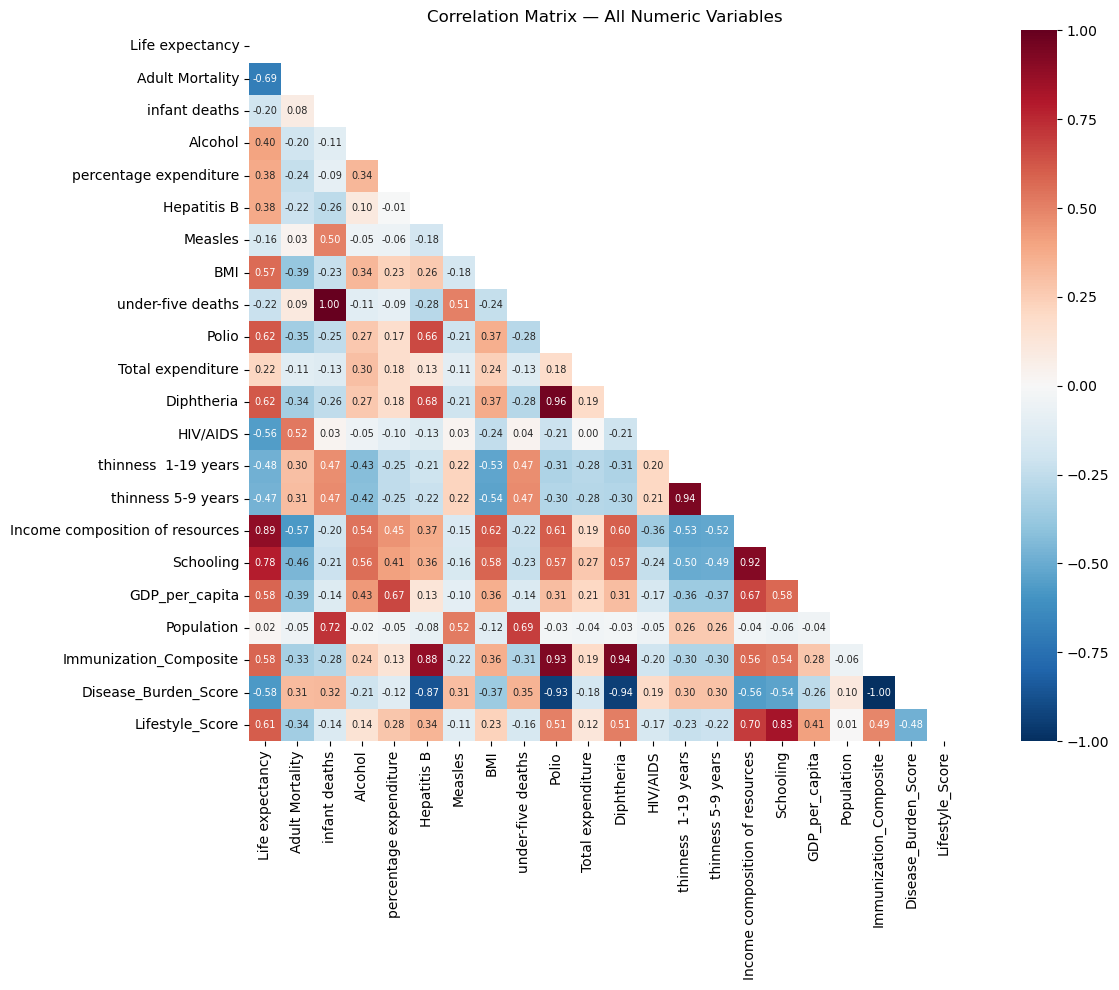

In [37]:
# Correlation heatmap — all numeric variables
fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = numeric_cols.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (redundant)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Correlation Matrix — All Numeric Variables')
plt.tight_layout()
plt.show()

In [38]:
# Partial correlations — isolate immunization effect after removing GDP/Region confounding
# This answers: does immunization still predict LE after accounting for wealth?
from sklearn.linear_model import LinearRegression

def partial_corr(df, x, y, controls):
    """Correlation between x and y after removing effect of control variables"""
    clean = df[[x, y] + controls].dropna()
    if len(clean) < 10:
        return np.nan, np.nan
    
    # Regress x on controls, get residuals
    reg_x = LinearRegression().fit(clean[controls], clean[x])
    resid_x = clean[x] - reg_x.predict(clean[controls])
    
    # Regress y on controls, get residuals
    reg_y = LinearRegression().fit(clean[controls], clean[y])
    resid_y = clean[y] - reg_y.predict(clean[controls])
    
    # Correlate residuals
    r, p = pearsonr(resid_x, resid_y)
    return r, p

# Need numeric Region for regression — one-hot encode
who_encoded = pd.get_dummies(who, columns=['WHO_Region'], drop_first=True)
region_cols = [c for c in who_encoded.columns if c.startswith('WHO_Region_')]
controls = ['GDP_per_capita'] + region_cols

# Test immunization variables
imm_vars = ['Polio', 'Diphtheria', 'Hepatitis B', 'Immunization_Composite']
print("Partial correlations with LE — controlling for GDP + Region:\n")
print(f"{'Variable':<30} {'Unadjusted r':>14} {'Partial r':>12} {'p-value':>12} {'Change':>10}")
print("-" * 80)

for var in imm_vars:
    # Unadjusted
    clean = who[['Life expectancy', var]].dropna()
    r_raw, _ = pearsonr(clean['Life expectancy'], clean[var])
    
    # Partial
    r_partial, p_partial = partial_corr(who_encoded, var, 'Life expectancy', controls)
    
    change = r_partial - r_raw
    print(f"{var:<30} {r_raw:>14.4f} {r_partial:>12.4f} {p_partial:>12.2e} {change:>+10.4f}")

print("\n— Negative change = confounding inflated the raw correlation")
print("— If partial r is still significant, immunization has independent effect on LE")

Partial correlations with LE — controlling for GDP + Region:

Variable                         Unadjusted r    Partial r      p-value     Change
--------------------------------------------------------------------------------
Polio                                  0.6225       0.4781    3.35e-164    -0.1444
Diphtheria                             0.6201       0.4783    1.06e-164    -0.1418
Hepatitis B                            0.3763       0.3252     2.15e-68    -0.0512
Immunization_Composite                 0.5795       0.4538    1.01e-146    -0.1257

— Negative change = confounding inflated the raw correlation
— If partial r is still significant, immunization has independent effect on LE


In [39]:
# OLS Regression — Life Expectancy predicted by all key variables
import statsmodels.api as sm

# Select predictor variables
predictors = ['Adult Mortality', 'Alcohol', 'percentage expenditure', 
              'Hepatitis B', 'Measles', 'BMI', 'under-five deaths',
              'Polio', 'Diphtheria', 'HIV/AIDS', 'GDP_per_capita',
              'thinness  1-19 years', 'Income composition of resources', 
              'Schooling']

# Drop rows with any NaN in predictors or target
reg_data = who[['Life expectancy'] + predictors].dropna()
X = reg_data[predictors]
y = reg_data['Life expectancy']

# Add constant (intercept)
X = sm.add_constant(X)

# Fit OLS
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     1362.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:16:04   Log-Likelihood:                -6280.3
No. Observations:                2461   AIC:                         1.259e+04
Df Residuals:                    2446   BIC:                         1.268e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [40]:
# VIF — Variance Inflation Factor
# VIF > 5 = concerning, VIF > 10 = severe multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use same X matrix from OLS (without constant)
X_vif = reg_data[predictors].dropna()
vif_data = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

vif_data['Flag'] = vif_data['VIF'].apply(lambda x: '⚠ SEVERE' if x > 10 else '⚠ High' if x > 5 else 'OK')
print("Variance Inflation Factors:\n")
print(vif_data.to_string(index=False))

Variance Inflation Factors:

                       Variable    VIF     Flag
                          Polio 538.61 ⚠ SEVERE
                     Diphtheria 524.29 ⚠ SEVERE
Income composition of resources 177.00 ⚠ SEVERE
                      Schooling 123.41 ⚠ SEVERE
                    Hepatitis B  34.72 ⚠ SEVERE
                            BMI   8.92   ⚠ High
                Adult Mortality   4.00       OK
           thinness  1-19 years   3.95       OK
                 GDP_per_capita   3.84       OK
                        Alcohol   3.52       OK
         percentage expenditure   2.35       OK
              under-five deaths   1.89       OK
                       HIV/AIDS   1.69       OK
                        Measles   1.46       OK


In [41]:
# Interaction: does GDP affect LE differently for Developed vs Developing?
reg_interact = who[['Life expectancy', 'GDP_per_capita', 'Status']].dropna()
reg_interact['Is_Developed'] = (reg_interact['Status'] == 'Developed').astype(int)
reg_interact['GDP_x_Status'] = reg_interact['GDP_per_capita'] * reg_interact['Is_Developed']

X_int = sm.add_constant(reg_interact[['GDP_per_capita', 'Is_Developed', 'GDP_x_Status']])
y_int = reg_interact['Life expectancy']
model_interact = sm.OLS(y_int, X_int).fit()

print(model_interact.summary())
print("\nInterpretation:")
print(f"  GDP effect for Developing: {model_interact.params['GDP_per_capita']:.6f} years per $1 GDP")
print(f"  Additional GDP effect for Developed: {model_interact.params['GDP_x_Status']:.6f}")
print(f"  Interaction significant: p = {model_interact.pvalues['GDP_x_Status']:.4f}")

                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     842.3
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:17:12   Log-Likelihood:                -9707.5
No. Observations:                2892   AIC:                         1.942e+04
Df Residuals:                    2888   BIC:                         1.945e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             63.2094      0.187    337.

In [42]:
# Residual analysis — which countries beat or miss their predicted LE?
reg_data_full = who[['Country', 'Year', 'Life expectancy'] + predictors].dropna()
X_full = sm.add_constant(reg_data_full[predictors])
y_full = reg_data_full['Life expectancy']
model_full = sm.OLS(y_full, X_full).fit()

reg_data_full['predicted_LE'] = model_full.predict(X_full)
reg_data_full['residual'] = reg_data_full['Life expectancy'] - reg_data_full['predicted_LE']

# Average residual per country (positive = overachiever, negative = underperformer)
country_residuals = reg_data_full.groupby('Country')['residual'].mean().sort_values()

print("=== TOP 10 OVERACHIEVERS (LE higher than predicted) ===")
print(country_residuals.tail(10).sort_values(ascending=False).to_string())
print(f"\n=== TOP 10 UNDERPERFORMERS (LE lower than predicted) ===")
print(country_residuals.head(10).to_string())

=== TOP 10 OVERACHIEVERS (LE higher than predicted) ===
Country
Vanuatu      5.70
Viet Nam     5.03
Nicaragua    4.87
Ethiopia     4.82
Honduras     4.62
Maldives     4.24
Costa Rica   3.78
Guatemala    3.76
Samoa        3.69
Cabo Verde   3.58

=== TOP 10 UNDERPERFORMERS (LE lower than predicted) ===
Country
Sierra Leone         -8.65
Angola               -8.07
Turkmenistan         -6.30
Kazakhstan           -6.29
Russian Federation   -5.76
Mongolia             -4.72
Equatorial Guinea    -4.46
Fiji                 -4.41
Cameroon             -4.35
Saudi Arabia         -4.14


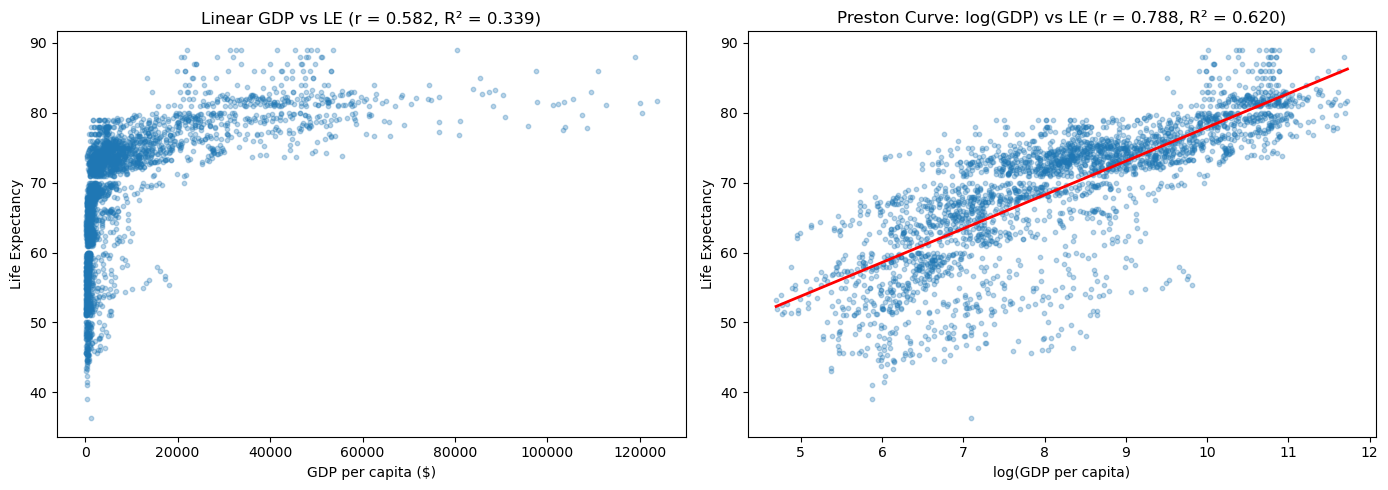


Linear R²: 0.339 — log R²: 0.620
Log transformation explains 28.2% more variance


In [43]:
# Preston Curve — formalised with R² on log(GDP)
from scipy.stats import pearsonr

preston = who[['Life expectancy', 'GDP_per_capita']].dropna()
preston['log_GDP'] = np.log(preston['GDP_per_capita'])

r_linear, _ = pearsonr(preston['GDP_per_capita'], preston['Life expectancy'])
r_log, _ = pearsonr(preston['log_GDP'], preston['Life expectancy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear
axes[0].scatter(preston['GDP_per_capita'], preston['Life expectancy'], alpha=0.3, s=10)
axes[0].set_xlabel('GDP per capita ($)')
axes[0].set_ylabel('Life Expectancy')
axes[0].set_title(f'Linear GDP vs LE (r = {r_linear:.3f}, R² = {r_linear**2:.3f})')

# Log — Preston Curve
axes[1].scatter(preston['log_GDP'], preston['Life expectancy'], alpha=0.3, s=10)
axes[1].set_xlabel('log(GDP per capita)')
axes[1].set_ylabel('Life Expectancy')
axes[1].set_title(f'Preston Curve: log(GDP) vs LE (r = {r_log:.3f}, R² = {r_log**2:.3f})')

# Add regression line
z = np.polyfit(preston['log_GDP'], preston['Life expectancy'], 1)
p = np.poly1d(z)
x_line = np.linspace(preston['log_GDP'].min(), preston['log_GDP'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r-', linewidth=2)

plt.tight_layout()
plt.show()

print(f"\nLinear R²: {r_linear**2:.3f} — log R²: {r_log**2:.3f}")
print(f"Log transformation explains {(r_log**2 - r_linear**2)*100:.1f}% more variance")

In [44]:
# Expanded partial correlations — all variables where GDP/Region confounding is plausible
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

def partial_corr(df, x, y, controls):
    clean = df[[x, y] + controls].dropna()
    if len(clean) < 10:
        return np.nan, np.nan
    reg_x = LinearRegression().fit(clean[controls], clean[x])
    resid_x = clean[x] - reg_x.predict(clean[controls])
    reg_y = LinearRegression().fit(clean[controls], clean[y])
    resid_y = clean[y] - reg_y.predict(clean[controls])
    r, p = pearsonr(resid_x, resid_y)
    return r, p

who_encoded = pd.get_dummies(who, columns=['WHO_Region'], drop_first=True)
region_cols = [c for c in who_encoded.columns if c.startswith('WHO_Region_')]
controls = ['GDP_per_capita'] + region_cols

# All variables where confounding with GDP is plausible
test_vars = ['Polio', 'Diphtheria', 'Hepatitis B', 'Immunization_Composite',
             'Schooling', 'percentage expenditure', 'Total expenditure',
             'Alcohol', 'BMI', 'HIV/AIDS', 'Adult Mortality',
             'thinness  1-19 years', 'Income composition of resources']

print("Partial correlations with LE — controlling for GDP + Region:\n")
print(f"{'Variable':<35} {'Raw r':>8} {'Partial r':>10} {'p-value':>12} {'Change':>8} {'% drop':>8}")
print("-" * 85)

for var in test_vars:
    if var not in who_encoded.columns:
        continue
    clean = who[['Life expectancy', var]].dropna()
    if len(clean) < 10:
        continue
    r_raw, _ = pearsonr(clean['Life expectancy'], clean[var])
    r_partial, p_partial = partial_corr(who_encoded, var, 'Life expectancy', controls)
    change = r_partial - r_raw
    pct_drop = (abs(r_raw) - abs(r_partial)) / abs(r_raw) * 100 if r_raw != 0 else 0
    print(f"{var:<35} {r_raw:>8.4f} {r_partial:>10.4f} {p_partial:>12.2e} {change:>+8.4f} {pct_drop:>7.1f}%")

print("\n— Large % drop = relationship was mostly confounding (driven by GDP/Region)")
print("— Small % drop = genuine independent effect on LE")
print("— Sign flip = relationship reverses after controlling for wealth")

Partial correlations with LE — controlling for GDP + Region:

Variable                               Raw r  Partial r      p-value   Change   % drop
-------------------------------------------------------------------------------------
Polio                                 0.6225     0.4781    3.35e-164  -0.1444    23.2%
Diphtheria                            0.6201     0.4783    1.06e-164  -0.1418    22.9%
Hepatitis B                           0.3763     0.3252     2.15e-68  -0.0512    13.6%
Immunization_Composite                0.5795     0.4538    1.01e-146  -0.1257    21.7%
Schooling                             0.7828     0.5370    4.63e-204  -0.2458    31.4%
percentage expenditure                0.3816    -0.0070     7.06e-01  -0.3886    98.2%
Total expenditure                     0.2166     0.0324     9.31e-02  -0.1842    85.1%
Alcohol                               0.4026     0.0250     1.79e-01  -0.3776    93.8%
BMI                                   0.5677     0.2284     2.31e-35 

In [45]:
# Reduced OLS — drop collinear variables for interpretable coefficients
# Rationale: VIF showed Polio/Diphtheria/HepB are redundant (VIF 500+) → use Immunization_Composite
#            ICOR and Schooling overlap (VIF 120-177) → keep ICOR (stronger predictor)
#            Thinness 1-19 and 5-9 are near-duplicates → keep 1-19 only
#            Under-five deaths overlaps with infant deaths → keep infant deaths

predictors_reduced = ['Adult Mortality', 'Alcohol', 'percentage expenditure',
                      'Immunization_Composite', 'Measles', 'BMI',
                      'infant deaths', 'HIV/AIDS', 'GDP_per_capita',
                      'thinness  1-19 years', 'Income composition of resources']

reg_data_r = who[['Life expectancy'] + predictors_reduced].dropna()
X_r = sm.add_constant(reg_data_r[predictors_reduced])
y_r = reg_data_r['Life expectancy']
model_reduced = sm.OLS(y_r, X_r).fit()

print(model_reduced.summary())

# VIF check on reduced model
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif_r = reg_data_r[predictors_reduced]
vif_reduced = pd.DataFrame({
    'Variable': X_vif_r.columns,
    'VIF': [variance_inflation_factor(X_vif_r.values, i) for i in range(X_vif_r.shape[1])]
}).sort_values('VIF', ascending=False)
vif_reduced['Flag'] = vif_reduced['VIF'].apply(lambda x: '⚠ SEVERE' if x > 10 else '⚠ High' if x > 5 else 'OK')

print("\nVIF — Reduced Model:")
print(vif_reduced.to_string(index=False))
print(f"\nFull model R²: 0.886 → Reduced model R²: {model_reduced.rsquared:.3f}")
print(f"Variables dropped: Schooling, Polio, Diphtheria, Hepatitis B, under-five deaths, thinness 5-9")

                            OLS Regression Results                            
Dep. Variable:        Life expectancy   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     1847.
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        12:36:51   Log-Likelihood:                -6687.9
No. Observations:                2609   AIC:                         1.340e+04
Df Residuals:                    2597   BIC:                         1.347e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

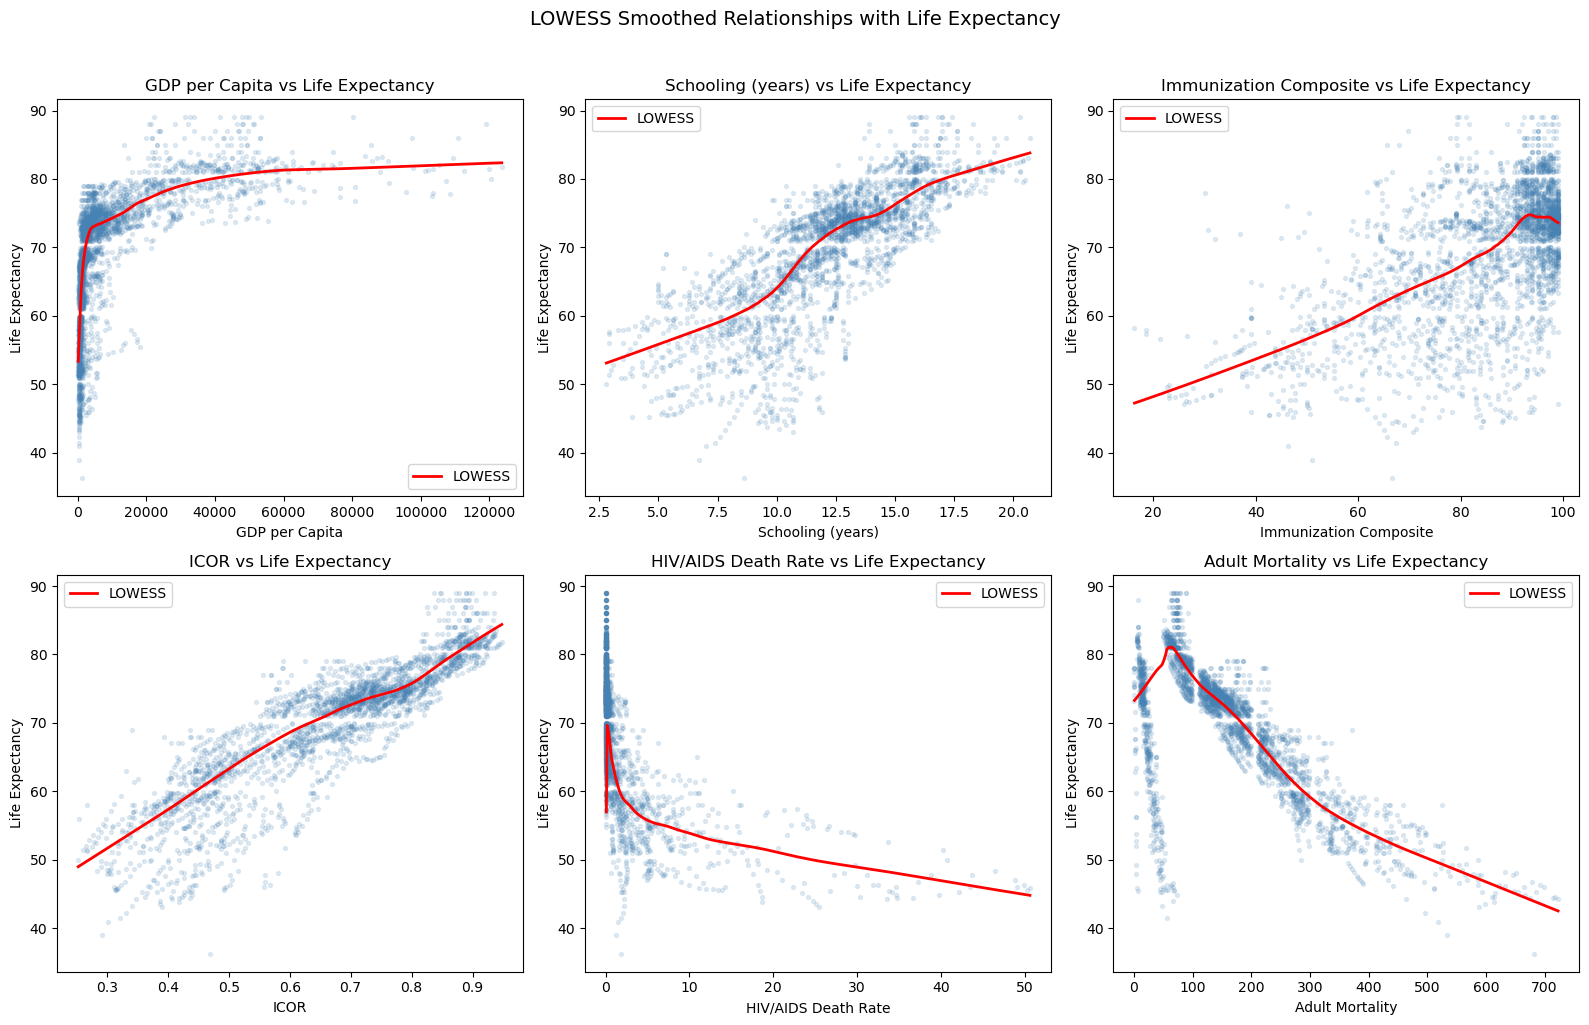

In [46]:
# LOWESS scatter plots — shows actual relationship shape, not forced linear fit
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plots = [
    ('GDP_per_capita', 'GDP per Capita'),
    ('Schooling', 'Schooling (years)'),
    ('Immunization_Composite', 'Immunization Composite'),
    ('Income composition of resources', 'ICOR'),
    ('HIV/AIDS', 'HIV/AIDS Death Rate'),
    ('Adult Mortality', 'Adult Mortality')
]

for ax, (col, title) in zip(axes.flatten(), plots):
    clean = who[['Life expectancy', col]].dropna()
    ax.scatter(clean[col], clean['Life expectancy'], alpha=0.15, s=8, color='steelblue')
    
    # LOWESS smoothing curve
    smooth = lowess(clean['Life expectancy'], clean[col], frac=0.3)
    ax.plot(smooth[:, 0], smooth[:, 1], color='red', linewidth=2, label='LOWESS')
    
    ax.set_xlabel(title)
    ax.set_ylabel('Life Expectancy')
    ax.set_title(f'{title} vs Life Expectancy')
    ax.legend()

plt.suptitle('LOWESS Smoothed Relationships with Life Expectancy', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()